In [2]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set random seed and device
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Data transformations for CIFAR-100 training and testing
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2761))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2761))
])

# Load CIFAR-100 dataset
cifar100_full = torchvision.datasets.CIFAR100(root='./datasets', train=True, download=True, transform=transform_train)
train_size = int(0.9 * len(cifar100_full))
val_size = len(cifar100_full) - train_size
cifar100_train, cifar100_val = random_split(cifar100_full, [train_size, val_size])
cifar100_test = torchvision.datasets.CIFAR100(root='./datasets', train=False, download=True, transform=transform_test)

batch_size = 128
train_loader = DataLoader(cifar100_train, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(cifar100_val, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(cifar100_test, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
# ResNet-18 Definition
class BasicBlockRes18(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlockRes18, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=100):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        # Use 3x3 convolution instead of 7x7 for CIFAR images
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlockRes18.expansion, num_classes)
        
    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlockRes18(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlockRes18(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [4]:
# Vision Transformer (ViT) Definition for CIFAR-100
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x shape: [B, C, H, W]
        x = self.proj(x)               # [B, embed_dim, H', W']
        x = x.flatten(2)               # [B, embed_dim, num_patches]
        x = x.transpose(1, 2)          # [B, num_patches, embed_dim]
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        x_norm = self.layer_norm1(x)
        attn_output, _ = self.attention(x_norm, x_norm, x_norm)
        x = x + attn_output
        x_norm = self.layer_norm2(x)
        mlp_output = self.mlp(x_norm)
        x = x + mlp_output
        return x

class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, embed_dim, 
                 num_heads, num_layers, mlp_dim, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels=3, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        
        self.transformer = nn.ModuleList([
            TransformerEncoder(embed_dim, num_heads, mlp_dim, dropout) for _ in range(num_layers)
        ])
        
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        
        self._init_weights()
        
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)           # [B, num_patches, embed_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)  # [B, num_patches+1, embed_dim]
        x = x + self.pos_embed
        x = self.dropout(x)
        
        for encoder in self.transformer:
            x = encoder(x)
            
        x = self.layer_norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        return x

In [5]:
# Initialize baseline models
resnet_model = ResNet18(num_classes=100).to(device)
print("ResNet18:")
print(resnet_model)

vit_default = VisionTransformer(
    image_size=32,
    patch_size=4,
    num_classes=100,
    embed_dim=256,
    num_heads=4,
    num_layers=4,
    mlp_dim=256 * 4,  # setting mlp_dim as 4 times embed_dim
    dropout=0.1
).to(device)
print("Default Vision Transformer:")
print(vit_default)

ResNet18:
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlockRes18(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlockRes18(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [6]:
# Helper function to count model parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("ResNet18 parameter count:", count_parameters(resnet_model))
print("Default ViT parameter count:", count_parameters(vit_default))

ResNet18 parameter count: 11220132
Default ViT parameter count: 3214692


In [7]:
# Define training and evaluation functions for both models
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(targets).sum().item()
            total += targets.size(0)
    return running_loss / len(dataloader.dataset), correct / total

In [8]:
# Set training hyperparameters
num_epochs = 50
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()

# Train ResNet18 baseline
print("Training ResNet18 baseline...")
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)
resnet_train_losses = []
resnet_val_losses = []
resnet_val_accuracies = []

for epoch in range(num_epochs):
    train_loss = train_epoch(resnet_model, train_loader, resnet_optimizer, criterion)
    val_loss, val_acc = evaluate(resnet_model, val_loader, criterion)
    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_val_accuracies.append(val_acc)
    print(f"ResNet Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training ResNet18 baseline...


ResNet Epoch 1/50: Train Loss: 3.8065, Val Loss: 3.6254, Val Acc: 0.1440
ResNet Epoch 2/50: Train Loss: 3.0850, Val Loss: 2.8734, Val Acc: 0.2650
ResNet Epoch 3/50: Train Loss: 2.5800, Val Loss: 2.5397, Val Acc: 0.3406
ResNet Epoch 4/50: Train Loss: 2.2191, Val Loss: 2.2064, Val Acc: 0.4074
ResNet Epoch 5/50: Train Loss: 1.9587, Val Loss: 2.0583, Val Acc: 0.4444
ResNet Epoch 6/50: Train Loss: 1.7518, Val Loss: 1.9416, Val Acc: 0.4698
ResNet Epoch 7/50: Train Loss: 1.5858, Val Loss: 1.8286, Val Acc: 0.5060
ResNet Epoch 8/50: Train Loss: 1.4319, Val Loss: 1.6358, Val Acc: 0.5470
ResNet Epoch 9/50: Train Loss: 1.3098, Val Loss: 1.6319, Val Acc: 0.5448
ResNet Epoch 10/50: Train Loss: 1.1919, Val Loss: 1.5764, Val Acc: 0.5690
ResNet Epoch 11/50: Train Loss: 1.0959, Val Loss: 1.4839, Val Acc: 0.5900
ResNet Epoch 12/50: Train Loss: 1.0017, Val Loss: 1.4912, Val Acc: 0.5904
ResNet Epoch 13/50: Train Loss: 0.9144, Val Loss: 1.4628, Val Acc: 0.6040
ResNet Epoch 14/50: Train Loss: 0.8341, Val Los

In [9]:
# Train Default ViT model
print("\nTraining Default Vision Transformer...")
vit_optimizer_default = optim.Adam(vit_default.parameters(), lr=learning_rate)
vit_train_losses = []
vit_val_losses = []
vit_val_accuracies = []

for epoch in range(num_epochs):
    train_loss = train_epoch(vit_default, train_loader, vit_optimizer_default, criterion)
    val_loss, val_acc = evaluate(vit_default, val_loader, criterion)
    vit_train_losses.append(train_loss)
    vit_val_losses.append(val_loss)
    vit_val_accuracies.append(val_acc)
    print(f"Default ViT Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Training Default Vision Transformer...
Default ViT Epoch 1/50: Train Loss: 4.0254, Val Loss: 3.7659, Val Acc: 0.1116
Default ViT Epoch 2/50: Train Loss: 3.5768, Val Loss: 3.4418, Val Acc: 0.1748
Default ViT Epoch 3/50: Train Loss: 3.3725, Val Loss: 3.2791, Val Acc: 0.2004
Default ViT Epoch 4/50: Train Loss: 3.2208, Val Loss: 3.1421, Val Acc: 0.2292
Default ViT Epoch 5/50: Train Loss: 3.0934, Val Loss: 3.0358, Val Acc: 0.2522
Default ViT Epoch 6/50: Train Loss: 2.9895, Val Loss: 3.0259, Val Acc: 0.2564
Default ViT Epoch 7/50: Train Loss: 2.8985, Val Loss: 2.9002, Val Acc: 0.2746
Default ViT Epoch 8/50: Train Loss: 2.7947, Val Loss: 2.8131, Val Acc: 0.2930
Default ViT Epoch 9/50: Train Loss: 2.7179, Val Loss: 2.7818, Val Acc: 0.2952
Default ViT Epoch 10/50: Train Loss: 2.6377, Val Loss: 2.7357, Val Acc: 0.3122
Default ViT Epoch 11/50: Train Loss: 2.5629, Val Loss: 2.6315, Val Acc: 0.3322
Default ViT Epoch 12/50: Train Loss: 2.4866, Val Loss: 2.6490, Val Acc: 0.3200
Default ViT Epoch 13/

In [10]:
# ViT Hyperparameter Configuration Comparison
vit_configs = [
    {"name": "Config1", "patch_size": 4, "embed_dim": 256, "num_layers": 4, "num_heads": 4, "mlp_dim": 256*4},
    {"name": "Config2", "patch_size": 4, "embed_dim": 256, "num_layers": 8, "num_heads": 4, "mlp_dim": 256*4},
    {"name": "Config3", "patch_size": 8, "embed_dim": 512, "num_layers": 4, "num_heads": 2, "mlp_dim": 512*4},
    {"name": "Config4", "patch_size": 8, "embed_dim": 512, "num_layers": 8, "num_heads": 4, "mlp_dim": 512*4},
]

vit_results = []
vit_config_models = []  # To store each trained model
vit_curve_results = []  # To store training curves for each configuration

for config in vit_configs:
    print("\n-------------------------------------------")
    print(f"Training ViT {config['name']} with parameters:")
    print(f"Patch size: {config['patch_size']}, Embed dim: {config['embed_dim']}, Num layers: {config['num_layers']}, Num heads: {config['num_heads']}, MLP dim: {config['mlp_dim']}")
    
    model_vit = VisionTransformer(
        image_size=32,
        patch_size=config["patch_size"],
        num_classes=100,
        embed_dim=config["embed_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        mlp_dim=config["mlp_dim"],
        dropout=0.1
    ).to(device)
    
    param_count = count_parameters(model_vit)
    optimizer_vit = optim.Adam(model_vit.parameters(), lr=learning_rate)
    train_losses = []
    val_losses = []
    val_accuracies = []
    epoch_times = []
    
    for epoch in range(num_epochs):
        start_time = time.time()
        train_loss = train_epoch(model_vit, train_loader, optimizer_vit, criterion)
        val_loss, val_acc = evaluate(model_vit, val_loader, criterion)
        elapsed = time.time() - start_time
        epoch_times.append(elapsed)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"{config['name']} - Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Time: {elapsed:.2f} sec")
    
    avg_epoch_time = sum(epoch_times) / num_epochs
    final_val_acc = val_accuracies[-1]
    
    vit_results.append({
        "config": config,
        "param_count": param_count,
        "final_val_acc": final_val_acc,
        "avg_epoch_time": avg_epoch_time
    })
    
    vit_config_models.append((config["name"], model_vit))
    vit_curve_results.append({
        "name": config["name"],
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies
    })
    
    print(f"{config['name']} finished: Params: {param_count}, Final Val Acc: {final_val_acc:.4f}, Avg Epoch Time: {avg_epoch_time:.2f} sec")

# Add default ViT training curves to the list for complete plotting
vit_curve_results.append({
    "name": "Default ViT",
    "train_losses": vit_train_losses,
    "val_losses": vit_val_losses,
    "val_accuracies": vit_val_accuracies
})


-------------------------------------------
Training ViT Config1 with parameters:
Patch size: 4, Embed dim: 256, Num layers: 4, Num heads: 4, MLP dim: 1024


Config1 - Epoch 1/50: Train Loss: 4.1167, Val Loss: 3.7624, Val Acc: 0.1130, Time: 8.85 sec
Config1 - Epoch 2/50: Train Loss: 3.6268, Val Loss: 3.4930, Val Acc: 0.1534, Time: 8.88 sec
Config1 - Epoch 3/50: Train Loss: 3.4137, Val Loss: 3.3370, Val Acc: 0.1950, Time: 8.84 sec
Config1 - Epoch 4/50: Train Loss: 3.2893, Val Loss: 3.2577, Val Acc: 0.2062, Time: 8.88 sec
Config1 - Epoch 5/50: Train Loss: 3.1824, Val Loss: 3.0903, Val Acc: 0.2402, Time: 8.90 sec
Config1 - Epoch 6/50: Train Loss: 3.0925, Val Loss: 3.0391, Val Acc: 0.2524, Time: 8.89 sec
Config1 - Epoch 7/50: Train Loss: 3.0010, Val Loss: 3.0063, Val Acc: 0.2558, Time: 8.89 sec
Config1 - Epoch 8/50: Train Loss: 2.9272, Val Loss: 2.9406, Val Acc: 0.2726, Time: 8.94 sec
Config1 - Epoch 9/50: Train Loss: 2.8613, Val Loss: 2.9201, Val Acc: 0.2756, Time: 8.92 sec
Config1 - Epoch 10/50: Train Loss: 2.7886, Val Loss: 2.8460, Val Acc: 0.2918, Time: 8.92 sec
Config1 - Epoch 11/50: Train Loss: 2.7129, Val Loss: 2.8016, Val Acc: 0.2956, T

In [11]:
# Summary Table of ViT Hyperparameter Comparison
print("\nViT Configurations Summary:")
for res in vit_results:
    cfg = res["config"]
    print(f"{cfg['name']}: Patch {cfg['patch_size']}, Embed {cfg['embed_dim']}, Layers {cfg['num_layers']}, Heads {cfg['num_heads']}, MLP {cfg['mlp_dim']} | Params: {res['param_count']} | Final Val Acc: {res['final_val_acc']*100:.2f}% | Avg Epoch Time: {res['avg_epoch_time']:.2f} sec")


ViT Configurations Summary:
Config1: Patch 4, Embed 256, Layers 4, Heads 4, MLP 1024 | Params: 3214692 | Final Val Acc: 37.64% | Avg Epoch Time: 8.86 sec
Config2: Patch 4, Embed 256, Layers 8, Heads 4, MLP 1024 | Params: 6373732 | Final Val Acc: 40.40% | Avg Epoch Time: 16.90 sec
Config3: Patch 8, Embed 512, Layers 4, Heads 2, MLP 2048 | Params: 12769892 | Final Val Acc: 6.34% | Avg Epoch Time: 7.58 sec
Config4: Patch 8, Embed 512, Layers 8, Heads 4, MLP 2048 | Params: 25379428 | Final Val Acc: 5.34% | Avg Epoch Time: 14.48 sec


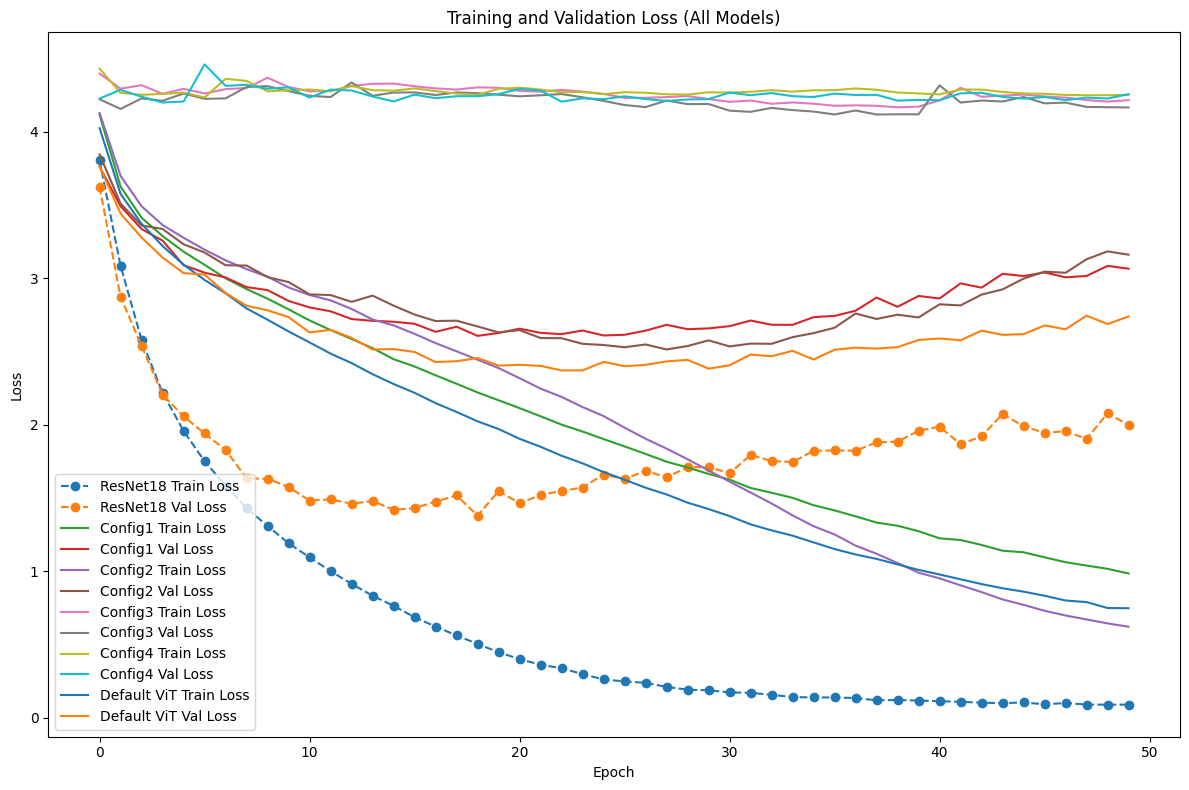

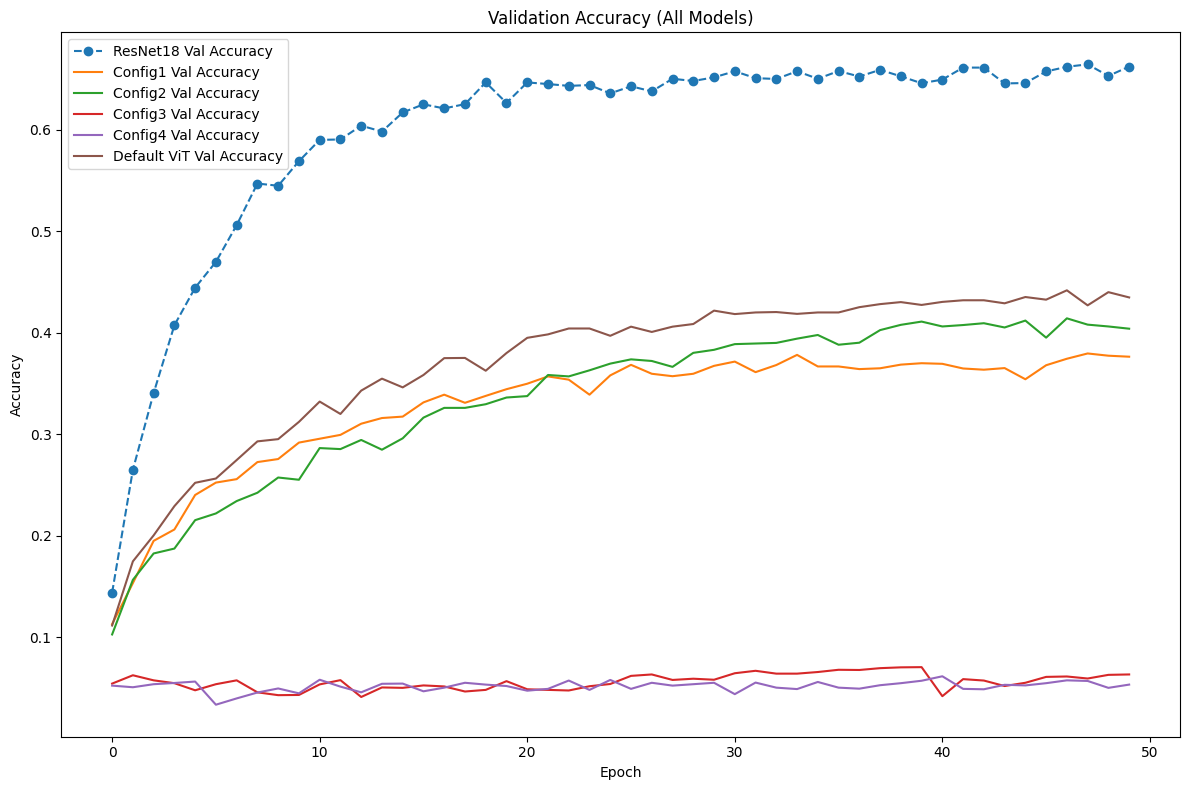

In [ ]:
# Plot training & validation curves for all models
plt.figure(figsize=(12, 8))
# Plot ResNet18 curves (using dashed lines for distinction)
plt.plot(resnet_train_losses, label='ResNet18 Train Loss', linestyle='--', marker='o')
plt.plot(resnet_val_losses, label='ResNet18 Val Loss', linestyle='--', marker='o')
# Plot Default ViT and Config curves
for data in vit_curve_results:
    plt.plot(data["train_losses"], label=f'{data["name"]} Train Loss')
    plt.plot(data["val_losses"], label=f'{data["name"]} Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (All Models)")
plt.legend()
plt.tight_layout()
plt.savefig("./images/p1_loss_comparison_all.png")
plt.show()

plt.figure(figsize=(12, 8))
# Plot ResNet18 validation accuracy (using dashed lines for distinction)
plt.plot(resnet_val_accuracies, label='ResNet18 Val Accuracy', linestyle='--', marker='o')
# Plot Default ViT and Config curves
for data in vit_curve_results:
    plt.plot(data["val_accuracies"], label=f'{data["name"]} Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy (All Models)")
plt.legend()
plt.tight_layout()
plt.savefig("./images/p1_accuracy_comparison_all.png")
plt.show()

In [13]:
# Define testing function to compute predictions
def compute_metrics(model, dataloader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_preds), np.array(all_targets)

# Evaluate all models on test set
print("\n----- Test Set Evaluation -----")
test_models = {
    "ResNet18": resnet_model,
    "Default ViT": vit_default
}
for name, model_vit in vit_config_models:
    test_models[name] = model_vit

for model_name, model_instance in test_models.items():
    preds, targets = compute_metrics(model_instance, test_loader)
    test_acc = np.mean(preds == targets)
    print(f"{model_name} Test Accuracy: {test_acc*100:.2f}%")


----- Test Set Evaluation -----
ResNet18 Test Accuracy: 65.86%
Default ViT Test Accuracy: 45.89%
Config1 Test Accuracy: 38.72%
Config2 Test Accuracy: 42.72%
Config3 Test Accuracy: 6.52%
Config4 Test Accuracy: 4.73%
